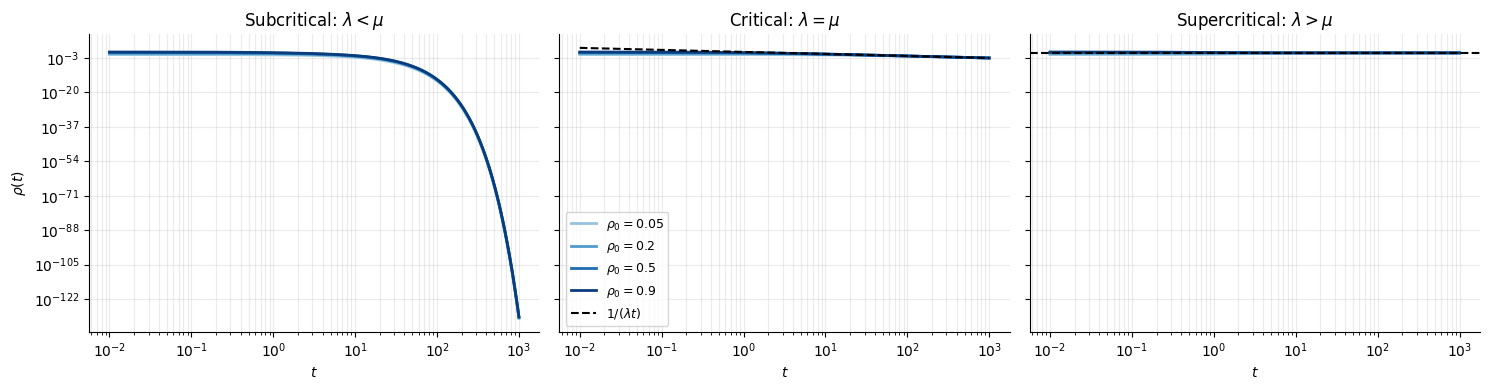

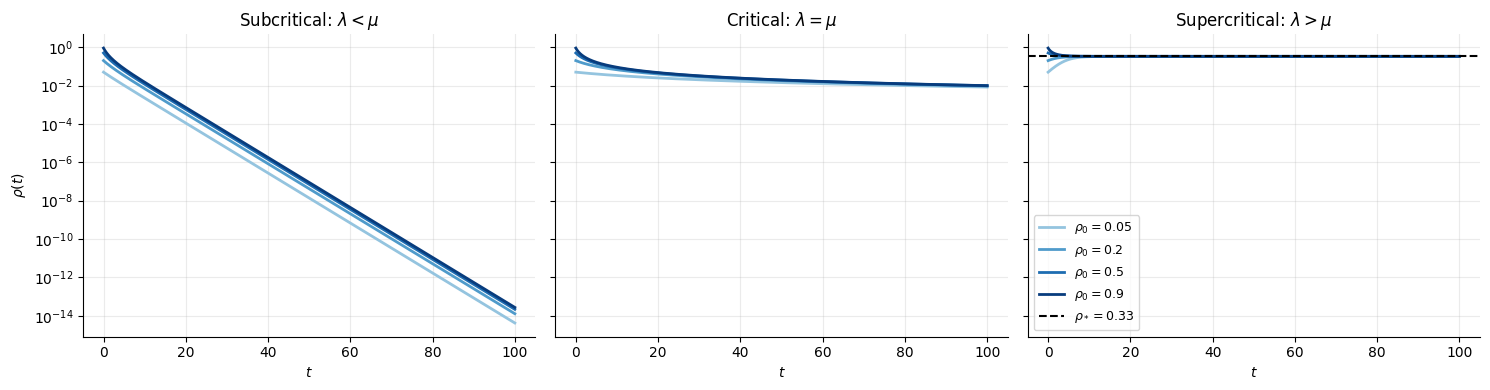

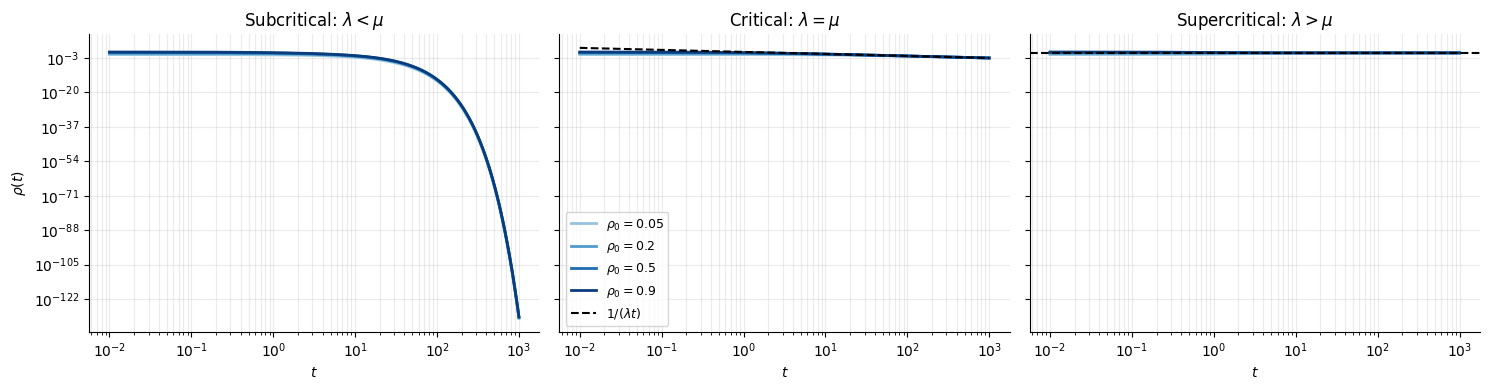

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def logistic_exact(t, rho0, lam, mu):
    """
    Exact solution of

        d rho/dt = (lam - mu) rho - lam rho^2
    """
    a = lam - mu

    # Critical case
    if np.isclose(a, 0):
        return rho0 / (1 + lam * rho0 * t)

    # Supercritical case: numerically stable form
    if a > 0:
        rho_star = a / lam

        return rho_star / (
            1 + (rho_star / rho0 - 1) * np.exp(-a * t)
        )

    # Subcritical case: numerically stable form
    exponential = np.exp(a * t)

    return (
        rho0 * exponential
        / (
            1
            + (lam * rho0 / a) * (exponential - 1)
        )
    )


rho_initials = [0.05, 0.2, 0.5, 0.9]

regimes = [
    (0.7, 1.0, r"Subcritical: $\lambda < \mu$"),
    (1.0, 1.0, r"Critical: $\lambda = \mu$"),
    (1.5, 1.0, r"Supercritical: $\lambda > \mu$")
]

colors = plt.cm.Blues(np.linspace(0.4, 0.95, len(rho_initials)))

# Start above zero because log(0) is undefined
t_log = np.logspace(-2, 3, 2000)

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4),
    sharex=True,
    sharey=True
)

for ax, (lam, mu, title) in zip(axes, regimes):
    for rho0, color in zip(rho_initials, colors):
        rho = logistic_exact(t_log, rho0, lam, mu)

        ax.loglog(
            t_log,
            rho,
            color=color,
            linewidth=2,
            label=fr"$\rho_0={rho0}$"
        )

    if np.isclose(lam, mu):
        # Late-time critical prediction: rho ~ 1/(lambda t)
        ax.loglog(
            t_log,
            1 / (lam * t_log),
            "k--",
            linewidth=1.5,
            label=r"$1/(\lambda t)$"
        )

    if lam > mu:
        rho_star = 1 - mu / lam
        ax.axhline(
            rho_star,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=fr"$\rho_*={rho_star:.2f}$"
        )

    ax.set_title(title)
    ax.set_xlabel(r"$t$")
    ax.grid(which="both", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel(r"$\rho(t)$")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

t_linear = np.linspace(0, 100, 2000)

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4),
    sharex=True,
    sharey=True
)

for ax, (lam, mu, title) in zip(axes, regimes):
    for rho0, color in zip(rho_initials, colors):
        rho = logistic_exact(t_linear, rho0, lam, mu)

        ax.semilogy(
            t_linear,
            rho,
            color=color,
            linewidth=2,
            label=fr"$\rho_0={rho0}$"
        )

    if lam > mu:
        rho_star = 1 - mu / lam
        ax.axhline(
            rho_star,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=fr"$\rho_*={rho_star:.2f}$"
        )

    ax.set_title(title)
    ax.set_xlabel(r"$t$")
    ax.grid(which="both", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel(r"$\rho(t)$")
axes[-1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Start above zero because log(0) is undefined
t_log = np.logspace(-2, 3, 2000)

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4),
    sharex=True,
    sharey=True
)

for ax, (lam, mu, title) in zip(axes, regimes):
    for rho0, color in zip(rho_initials, colors):
        rho = logistic_exact(t_log, rho0, lam, mu)

        ax.loglog(
            t_log,
            rho,
            color=color,
            linewidth=2,
            label=fr"$\rho_0={rho0}$"
        )

    if np.isclose(lam, mu):
        # Late-time critical prediction: rho ~ 1/(lambda t)
        ax.loglog(
            t_log,
            1 / (lam * t_log),
            "k--",
            linewidth=1.5,
            label=r"$1/(\lambda t)$"
        )

    if lam > mu:
        rho_star = 1 - mu / lam
        ax.axhline(
            rho_star,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label=fr"$\rho_*={rho_star:.2f}$"
        )

    ax.set_title(title)
    ax.set_xlabel(r"$t$")
    ax.grid(which="both", alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel(r"$\rho(t)$")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()